# ML BTC

## Imports

In [ ]:
import os
import requests
from datetime import datetime

import kagglehub
import polars as pl
from matplotlib import pyplot, dates

from sklearn.model_selection import train_test_split

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import set_config

## Dataset loading

### Bitcoin historical data

In [82]:
path = kagglehub.dataset_download("adilshamim8/bitcoin-historical-data")
filename = "Bitcoin_history_data.csv"
filepath = os.path.join(path, filename)
df_btc = pl.read_csv(filepath)
df_btc

Date,Close,High,Low,Open,Volume
str,f64,f64,f64,f64,i64
"""2014-09-17""",457.334015,468.174011,452.421997,465.864014,21056800
"""2014-09-18""",424.440002,456.859985,413.104004,456.859985,34483200
"""2014-09-19""",394.79599,427.834991,384.532013,424.102997,37919700
"""2014-09-20""",408.903992,423.29599,389.882996,394.673004,36863600
"""2014-09-21""",398.821014,412.425995,393.181,408.084991,26580100
…,…,…,…,…,…
"""2026-02-16""",68843.15625,70067.234375,67301.585938,68782.398438,33618145426
"""2026-02-17""",67494.21875,69201.867188,66615.28125,68843.09375,34866936040
"""2026-02-18""",66425.320312,68434.429688,65845.898438,67488.023438,33094301643


### Fear and greed index

In [83]:
url = "https://api.alternative.me/fng/?limit=0&format=json"
response = requests.get(url)
data = response.json()["data"]

rows = []
for row in data:
    timestamp = int(row["timestamp"])
    date = str(datetime.fromtimestamp(timestamp).date())
    value = int(row["value"])
    classification = row["value_classification"]
    rows.append({"Date": date, "Fear and greed index value": value, "Fear and greed index classification": classification})

df_fear_and_greed = pl.DataFrame(rows)
df_fear_and_greed

Date,Fear and greed index value,Fear and greed index classification
str,i64,str
"""2026-03-04""",10,"""Extreme Fear"""
"""2026-03-03""",14,"""Extreme Fear"""
"""2026-03-02""",10,"""Extreme Fear"""
"""2026-03-01""",14,"""Extreme Fear"""
"""2026-02-28""",11,"""Extreme Fear"""
…,…,…
"""2018-02-05""",11,"""Extreme Fear"""
"""2018-02-04""",24,"""Extreme Fear"""
"""2018-02-03""",40,"""Fear"""


### Dataset merging

In [84]:
df = df_btc.join(df_fear_and_greed, on="Date", how="outer")
df

/tmp/ipykernel_1209/317962971.py:1: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  df = df_btc.join(df_fear_and_greed, on="Date", how="outer")


Date,Close,High,Low,Open,Volume,Date_right,Fear and greed index value,Fear and greed index classification
str,f64,f64,f64,f64,i64,str,i64,str
"""2014-09-17""",457.334015,468.174011,452.421997,465.864014,21056800,null,null,null
"""2014-09-18""",424.440002,456.859985,413.104004,456.859985,34483200,null,null,null
"""2014-09-19""",394.79599,427.834991,384.532013,424.102997,37919700,null,null,null
"""2014-09-20""",408.903992,423.29599,389.882996,394.673004,36863600,null,null,null
"""2014-09-21""",398.821014,412.425995,393.181,408.084991,26580100,null,null,null
…,…,…,…,…,…,…,…,…
null,null,null,null,null,null,"""2026-02-27""",13,"""Extreme Fear"""
null,null,null,null,null,null,"""2026-02-23""",5,"""Extreme Fear"""
null,null,null,null,null,null,"""2026-02-21""",8,"""Extreme Fear"""


## EDA

### Basic statistics

In [85]:
df.describe()

statistic,Date,Close,High,Low,Open,Volume,Date_right,Fear and greed index value,Fear and greed index classification
str,str,f64,f64,f64,f64,f64,str,f64,str
"""count""","""4175""",4175.0,4175.0,4175.0,4175.0,4175.0,"""2950""",2950.0,"""2950"""
"""null_count""","""12""",12.0,12.0,12.0,12.0,12.0,"""1237""",1237.0,"""1237"""
"""mean""",null,27526.06214,28059.745781,26923.354242,27510.889452,2.1929e10,null,46.591186,null
"""std""",null,32063.847047,32602.934957,31471.308078,32061.131458,2.3023e10,null,21.897268,null
"""min""","""2014-09-17""",178.102997,211.731003,171.509995,176.897003,5.91457e6,"""2018-02-01""",5.0,"""Extreme Fear"""
"""25%""",null,2809.01001,2899.330078,2692.800049,2807.02002,1.3862e9,null,27.0,null
"""50%""",null,10978.459961,11349.799805,10669.321289,10978.299805,1.7275e10,null,46.0,null
"""75%""",null,43084.671875,43860.699219,42207.289062,43077.640625,3.3748e10,null,65.0,null
"""max""","""2026-02-20""",124752.53125,126198.070312,123196.046875,124752.140625,3.5097e11,"""2026-03-04""",95.0,"""Neutral"""


### BTC close price & fear and greed index

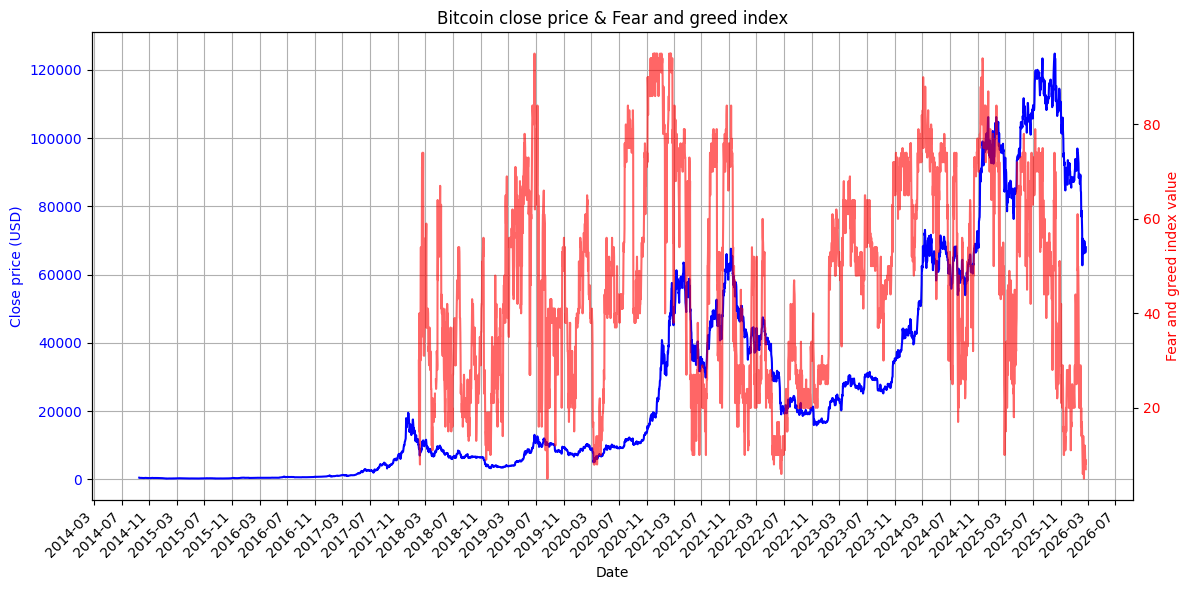

In [90]:
df_tmp = df.clone()
df_tmp = df_tmp.with_columns(
    pl.col("Date").str.strptime(pl.Datetime, format="%Y-%m-%d")
)

df_tmp = df_tmp.select(["Date", "Close", "Fear and greed index value"]).to_pandas()

fig, ax1 = pyplot.subplots(figsize=(12,6))

# close price
ax1.plot(df_tmp["Date"], df_tmp["Close"], color="blue", label="BTC close price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Close price (USD)", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.grid(True)

# fear and greed index
ax2 = ax1.twinx()
ax2.plot(df_tmp["Date"], df_tmp["Fear and greed index value"], color="red", label="Fear and greed index", alpha=0.6)
ax2.set_ylabel("Fear and greed index value", color="red")
ax2.tick_params(axis='y', labelcolor="red")

ax1.xaxis.set_major_locator(dates.MonthLocator(interval=4))
ax1.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m'))
for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

pyplot.title("Bitcoin close price & Fear and greed index")
pyplot.tight_layout()
pyplot.show()

### BTC close price & volume

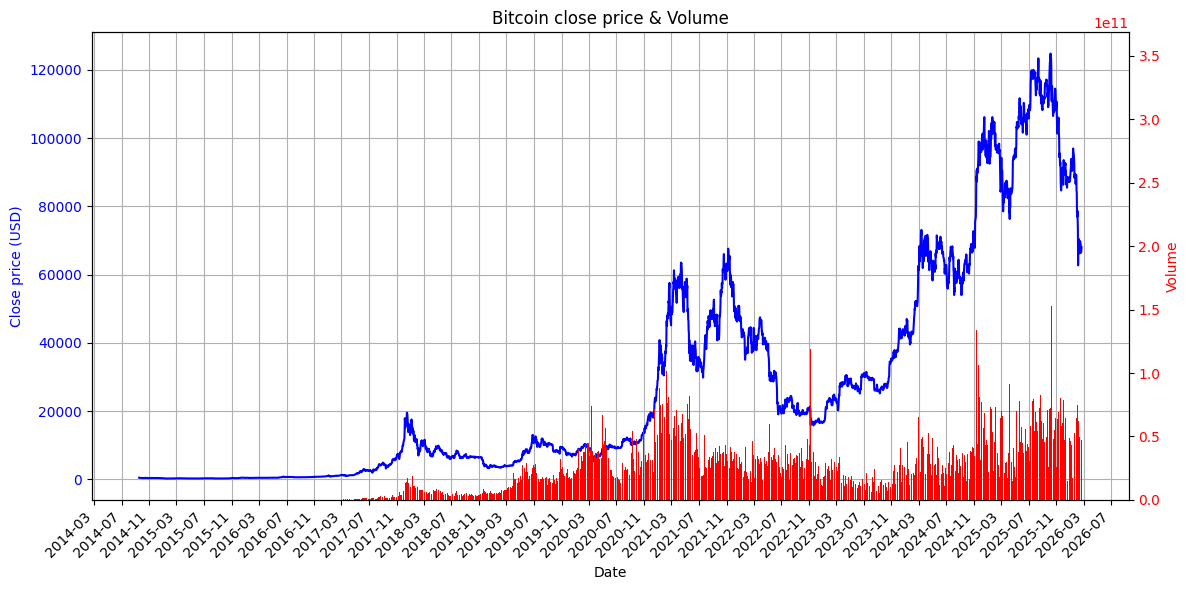

In [91]:
df_tmp = df.clone()
df_tmp = df_tmp.with_columns(
    pl.col("Date").str.strptime(pl.Datetime, format="%Y-%m-%d")
)

df_tmp = df_tmp.select(["Date", "Close", "Volume"]).to_pandas()

fig, ax1 = pyplot.subplots(figsize=(12,6))

# close price
ax1.plot(df_tmp["Date"], df_tmp["Close"], color="blue", label="BTC close price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Close price (USD)", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.grid(True)

# volume 
ax2 = ax1.twinx()
ax2.bar(df_tmp["Date"], df_tmp["Volume"], color="red", label="Volume")
ax2.set_ylabel("Volume", color="red")
ax2.tick_params(axis='y', labelcolor="red")

ax1.xaxis.set_major_locator(dates.MonthLocator(interval=4))
ax1.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m'))
for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

pyplot.title("Bitcoin close price & Volume")
pyplot.tight_layout()
pyplot.show()

### Fear and greed distribution

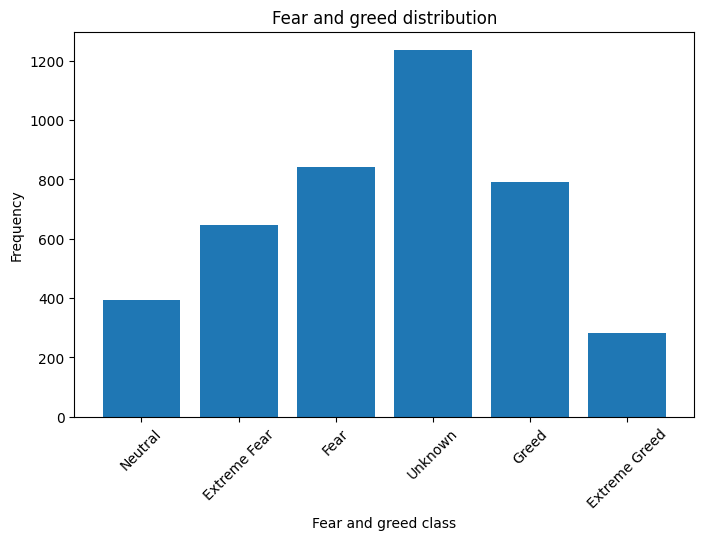

In [92]:
df_tmp = df.clone()

df_tmp = df.with_columns(
    pl.col("Fear and greed index classification")
    .fill_null("Unknown")
)
df_tmp = df_tmp.group_by("Fear and greed index classification").len()
df_tmp = df_tmp.to_pandas()

pyplot.figure(figsize=(8,5))
pyplot.bar(df_tmp["Fear and greed index classification"], df_tmp["len"])
pyplot.xlabel("Fear and greed class")
pyplot.ylabel("Frequency")
pyplot.title("Fear and greed distribution")
pyplot.xticks(rotation=45)
pyplot.show()

## Labeling

The current dataset does not contain any labels, so we need to assign the following labels to each row:
- Buy zone: favorable conditions for buying
- Sell zone: favorable conditions for selling
- Neutral zone: hold (HODL)

Methodology :
1. The dataset is divided into distinct periods.
2. Each period ends when a 50% drawdown from the ATH (All-Time High), calculated using the closing price, occurs.
3. A period is defined as follows:
    - From the beginning of the dataset to the first 50% drawdown
    - From one 50% drawdown to the next 50% drawdown
    - From the last 50% drawdown to the end of the dataset
4. For each period:
    1. The lowest and highest prices are identified.
    2. A Fibonacci retracement is applied from the highest price to the lowest price.
    3. The zones are defined as follows:
        - 0 ≤ price ≤ 0.236: Buy zone
        - 0.236 < price < 0.764: Neutral zone
        - 0.764 ≤ price ≤ 1: Sell zone

In [93]:
df_tmp = df.clone()
df_tmp = df_tmp.drop_nulls(subset=["Date", "Close"])
df_tmp = df_tmp.select(["Date", "Close"])
df_tmp = df_tmp.with_columns(
    pl.col("Date").str.strptime(pl.Datetime, format="%Y-%m-%d")
)
df_tmp = df_tmp.sort("Date")

# calculate ATH
df_tmp = df_tmp.with_columns(
    pl.col("Close").cum_max()
    .alias("ATH")
)

# calculate drawdown from ATH (0 to -1)
df_tmp = df_tmp.with_columns(
    (pl.col("Close") / pl.col("ATH") - 1).alias("Drawdown")
)

# determine periods based on drawdown >50% after a new ATH ()
df_tmp_pd = df_tmp.to_pandas()

period_id = 0
last_ath_for_period = df_tmp_pd.loc[0, "ATH"]
period_ids = []

for idx, row in df_tmp_pd.iterrows():
    if row["Drawdown"] < -0.5 and row["ATH"] > last_ath_for_period:
        period_id += 1
        last_ath_for_period = row["ATH"]
    period_ids.append(period_id)

df_tmp_pd["Period ID"] = period_ids
df_tmp = pl.from_pandas(df_tmp_pd)

# calculate the local low and high for each period
df_tmp = df_tmp.with_columns([
    pl.col("Close").min().over("Period ID").alias("Local Low"),
    pl.col("Close").max().over("Period ID").alias("Local High")
])

# calculate Fibonacci level
df_tmp = df_tmp.with_columns(
    (
        (pl.col("Close") - pl.col("Local Low")) / (pl.col("Local High") - pl.col("Local Low"))
    )
    .alias("Fibbonacci level")
)

# label based on Fibonacci retracement
df_tmp = df_tmp.with_columns(
    pl.when(pl.col("Fibbonacci level") <= 0.236).then(pl.lit("Buy zone"))
        .when(pl.col("Fibbonacci level") >= 0.764).then(pl.lit("Sell zone"))
        .otherwise(pl.lit("Neutral Zone"))
    .alias("Label")
)

# merging
df_tmp = df_tmp.select(["Date", "Label", "Period ID"])
df_tmp = df_tmp.with_columns(
    pl.col("Date").dt.strftime("%Y-%m-%d")
    .alias("Date")
)
df = df.join(df_tmp, on="Date", how="inner")
df


Date,Close,High,Low,Open,Volume,Date_right,Fear and greed index value,Fear and greed index classification,Label,Period ID
str,f64,f64,f64,f64,i64,str,i64,str,str,i64
"""2014-09-17""",457.334015,468.174011,452.421997,465.864014,21056800,null,null,null,"""Buy zone""",0
"""2014-09-18""",424.440002,456.859985,413.104004,456.859985,34483200,null,null,null,"""Buy zone""",0
"""2014-09-19""",394.79599,427.834991,384.532013,424.102997,37919700,null,null,null,"""Buy zone""",0
"""2014-09-20""",408.903992,423.29599,389.882996,394.673004,36863600,null,null,null,"""Buy zone""",0
"""2014-09-21""",398.821014,412.425995,393.181,408.084991,26580100,null,null,null,"""Buy zone""",0
…,…,…,…,…,…,…,…,…,…,…
"""2026-02-16""",68843.15625,70067.234375,67301.585938,68782.398438,33618145426,"""2026-02-16""",12,"""Extreme Fear""","""Neutral Zone""",3
"""2026-02-17""",67494.21875,69201.867188,66615.28125,68843.09375,34866936040,"""2026-02-17""",10,"""Extreme Fear""","""Neutral Zone""",3
"""2026-02-18""",66425.320312,68434.429688,65845.898438,67488.023438,33094301643,"""2026-02-18""",8,"""Extreme Fear""","""Neutral Zone""",3


### Data visualization

#### BTC close price with periods

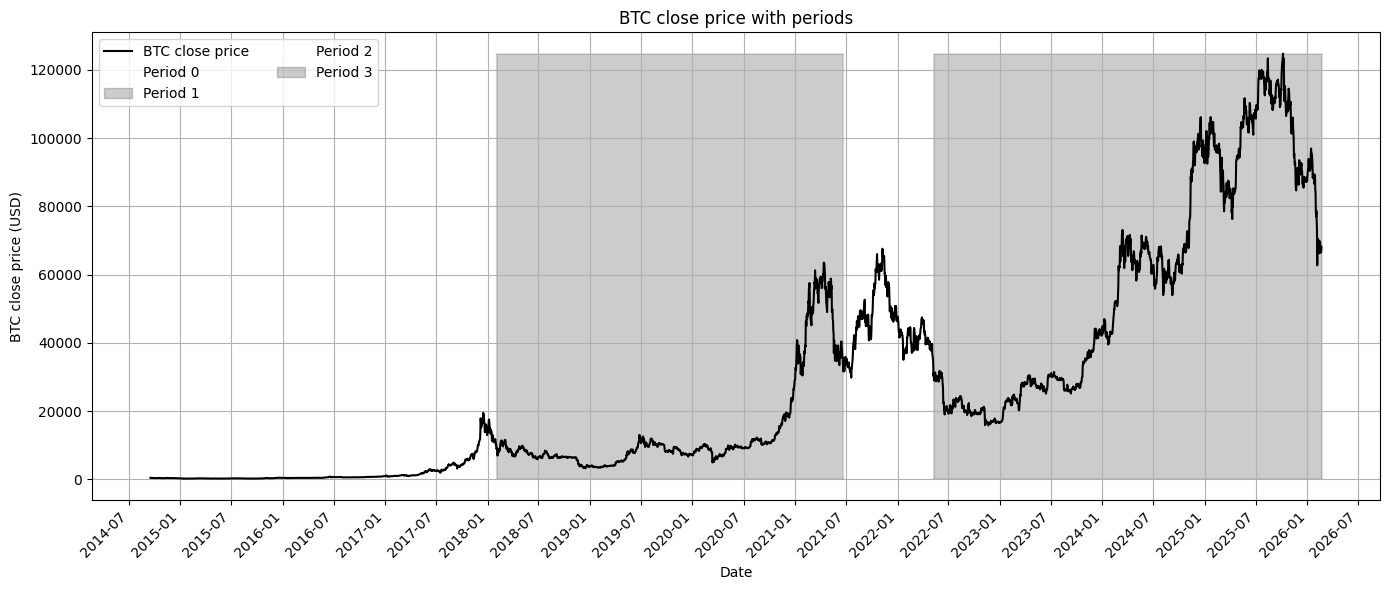

In [94]:
df_tmp = df.clone()
df_tmp = df_tmp.with_columns(
    pl.col("Date").str.strptime(pl.Datetime, format="%Y-%m-%d")
)

df_plot = df_tmp.select(["Date", "Close", "Period ID"]).to_pandas()

fig, ax = pyplot.subplots(figsize=(14,6))

# btc close price
ax.plot(df_plot["Date"], df_plot["Close"], color="black", label="BTC close price")

# zones
num_periods = df_plot["Period ID"].nunique()

colors = ["white", "black"]
for i, pid in enumerate(sorted(df_plot["Period ID"].unique())):
    color = colors[i % len(colors)] 
    mask = df_plot["Period ID"] == pid
    ax.fill_between(df_plot["Date"], df_plot["Close"].min(), df_plot["Close"].max(),
                    where=mask, color=color, alpha=0.2, label=f"Period {pid}")

ax.xaxis.set_major_locator(dates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m'))
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

ax.set_xlabel("Date")
ax.set_ylabel("BTC close price (USD)")
ax.set_title("BTC close price with periods")
ax.legend(loc="upper left", ncol=2)
ax.grid(True)

pyplot.tight_layout()
pyplot.show()

#### BTC close price with Buy / Sell / Neutral zones

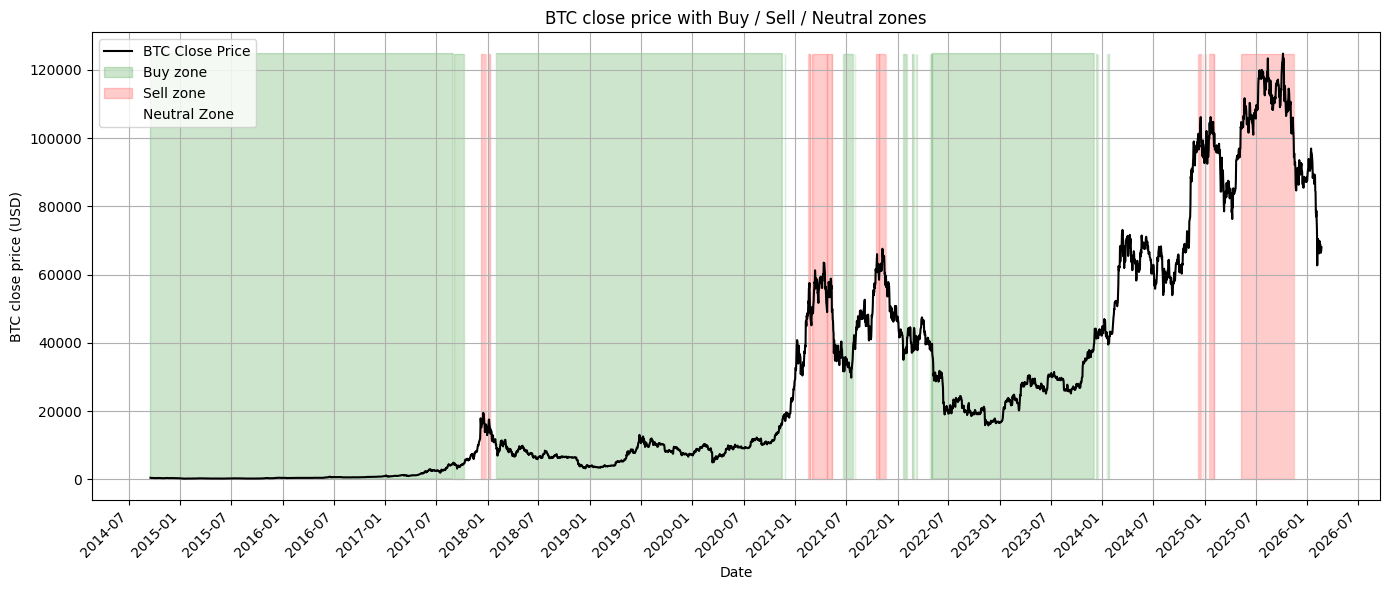

In [95]:
df_tmp = df.clone()
df_tmp = df_tmp.with_columns(
    pl.col("Date").str.strptime(pl.Datetime, format="%Y-%m-%d")
)

df_tmp = df_tmp.select(["Date", "Close", "Label"]).to_pandas()

fig, ax = pyplot.subplots(figsize=(14,6))

# btc close price
ax.plot(df_tmp["Date"], df_tmp["Close"], color="black", label="BTC Close Price")

# zones
colors = {"Buy zone": "green", "Sell zone": "red", "Neutral Zone": "white"}
for label, color in colors.items():
    mask = df_tmp["Label"] == label
    ax.fill_between(df_tmp["Date"], df_tmp["Close"].min(), df_tmp["Close"].max(),
                    where=mask, color=color, alpha=0.2, label=label)

ax.xaxis.set_major_locator(dates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m'))
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

ax.set_xlabel("Date")
ax.set_ylabel("BTC close price (USD)")
ax.set_title("BTC close price with Buy / Sell / Neutral zones")
ax.legend(loc="upper left")
ax.grid(True)

pyplot.tight_layout()
pyplot.show()

### Label distribution

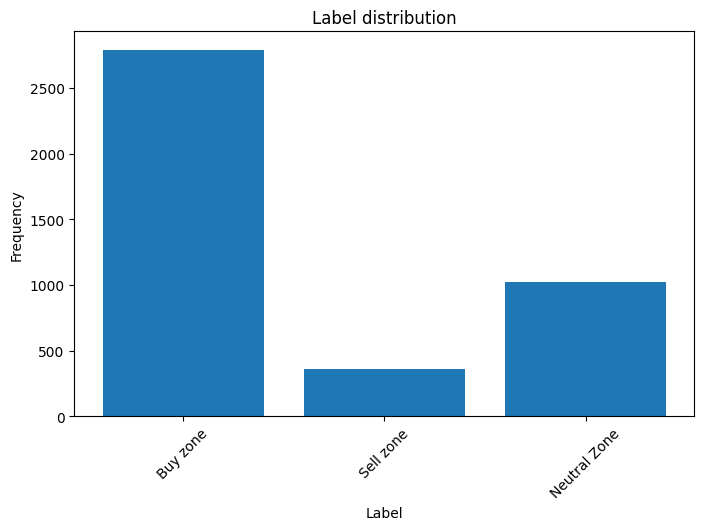

In [96]:
df_tmp = df.clone()

df_tmp = df_tmp.group_by("Label").len()
df_tmp = df_tmp.to_pandas()

pyplot.figure(figsize=(8,5))
pyplot.bar(df_tmp["Label"], df_tmp["len"])
pyplot.xlabel("Label")
pyplot.ylabel("Frequency")
pyplot.title("Label distribution")
pyplot.xticks(rotation=45)
pyplot.show()

## Technical indicators calculation

These indicators are calculated before the train/test split because they are based only on the preceding N days of data.
Without this historical data, it would not be possible to compute these indicators.

### Weekly data

Some indicators are calculated on a weekly basis because this is more appropriate for long-term analysis.

In [97]:
df = df.with_columns(
    pl.col("Date").str.strptime(pl.Datetime, format="%Y-%m-%d")
    .alias("Week")
)

df = df.with_columns(
    pl.col("Week").dt.strftime("%Y-%U")
    .alias("Week")
)

df_tmp = df.clone()

df_tmp = df_tmp.with_columns(
    pl.col("Date").str.strptime(pl.Datetime, format="%Y-%m-%d")
    .alias("Date")
)

df_tmp = df_tmp.filter(pl.col("Date").dt.weekday() == 7) 
df_weekly = df_tmp.select(["Week", "Close"])
df_weekly

Week,Close
str,f64
"""2014-38""",398.821014
"""2014-39""",377.181
"""2014-40""",320.51001
"""2014-41""",378.549011
"""2014-42""",389.54599
…,…
"""2026-03""",93634.429688
"""2026-04""",86572.21875
"""2026-05""",76974.445312


### Relative Strength Index (RSI)

This index measures both the strength and the speed of a price movement.
A value above 70 indicates that BTC is overbought, while a value below 30 indicates that BTC is oversold.
For the long term, the 14-period weekly RSI (standard indicator developed by J. Welles Wilder) is the most appropriate indicator.

Formula:

RSI(n) = 100 - 100 / (1 + RS(n))

RS(n) = AverageGain(n) / AverageLoss(n)

#### Calculation

In [98]:
rsi_period = 14

df_rsi = df_weekly.with_columns(
    (pl.col("Close").diff()).alias("Delta")
)

df_rsi = df_rsi.with_columns([
    pl.when(pl.col("Delta") > 0).then(pl.col("Delta")).otherwise(0).alias("Gain"),
    pl.when(pl.col("Delta") < 0).then(-pl.col("Delta")).otherwise(0).alias("Loss")
])

# 14-period exponential moving average
df_rsi = df_rsi.with_columns([
    pl.col("Gain").ewm_mean(span=rsi_period).alias("Average gain"),
    pl.col("Loss").ewm_mean(span=rsi_period).alias("Average loss")
])

df_rsi = df_rsi.with_columns([
    (100 - 100 / (1 + pl.col("Average gain") / pl.col("Average loss"))).alias("14-period weekly RSI")
])
df_rsi

Week,Close,Delta,Gain,Loss,Average gain,Average loss,14-period weekly RSI
str,f64,f64,f64,f64,f64,f64,f64
"""2014-38""",398.821014,null,0.0,0.0,0.0,0.0,NaN
"""2014-39""",377.181,-21.640015,0.0,21.640015,0.0,11.592865,0.0
"""2014-40""",320.51001,-56.67099,0.0,56.67099,0.0,28.812862,0.0
"""2014-41""",378.549011,58.039001,58.039001,0.0,17.755768,19.998195,47.03021
"""2014-42""",389.54599,10.996979,10.996979,0.0,15.99241,14.780696,51.968787
…,…,…,…,…,…,…,…
"""2026-03""",93634.429688,2806.96875,2806.96875,0.0,1430.881683,1731.215515,45.251034
"""2026-04""",86572.21875,-7062.210938,0.0,7062.210938,1240.097459,2442.014904,33.678968
"""2026-05""",76974.445312,-9597.773438,0.0,9597.773438,1074.751131,3396.116042,24.038986


#### Merging

In [99]:
df_rsi = df_rsi.select(["Week", "14-period weekly RSI"])
df = df.join(df_rsi, on="Week", how="inner")
df

Date,Close,High,Low,Open,Volume,Date_right,Fear and greed index value,Fear and greed index classification,Label,Period ID,Week,14-period weekly RSI
str,f64,f64,f64,f64,i64,str,i64,str,str,i64,str,f64
"""2014-09-21""",398.821014,412.425995,393.181,408.084991,26580100,null,null,null,"""Buy zone""",0,"""2014-38""",NaN
"""2014-09-22""",402.152008,406.915985,397.130005,399.100006,24127600,null,null,null,"""Buy zone""",0,"""2014-38""",NaN
"""2014-09-23""",435.790985,441.557007,396.196991,402.09201,45099500,null,null,null,"""Buy zone""",0,"""2014-38""",NaN
"""2014-09-24""",423.204987,436.112,421.131989,435.751007,30627700,null,null,null,"""Buy zone""",0,"""2014-38""",NaN
"""2014-09-25""",411.574005,423.519989,409.467987,423.156006,26814400,null,null,null,"""Buy zone""",0,"""2014-38""",NaN
…,…,…,…,…,…,…,…,…,…,…,…,…
"""2026-02-16""",68843.15625,70067.234375,67301.585938,68782.398438,33618145426,"""2026-02-16""",12,"""Extreme Fear""","""Neutral Zone""",3,"""2026-07""",18.641918
"""2026-02-17""",67494.21875,69201.867188,66615.28125,68843.09375,34866936040,"""2026-02-17""",10,"""Extreme Fear""","""Neutral Zone""",3,"""2026-07""",18.641918
"""2026-02-18""",66425.320312,68434.429688,65845.898438,67488.023438,33094301643,"""2026-02-18""",8,"""Extreme Fear""","""Neutral Zone""",3,"""2026-07""",18.641918


#### Data visualization

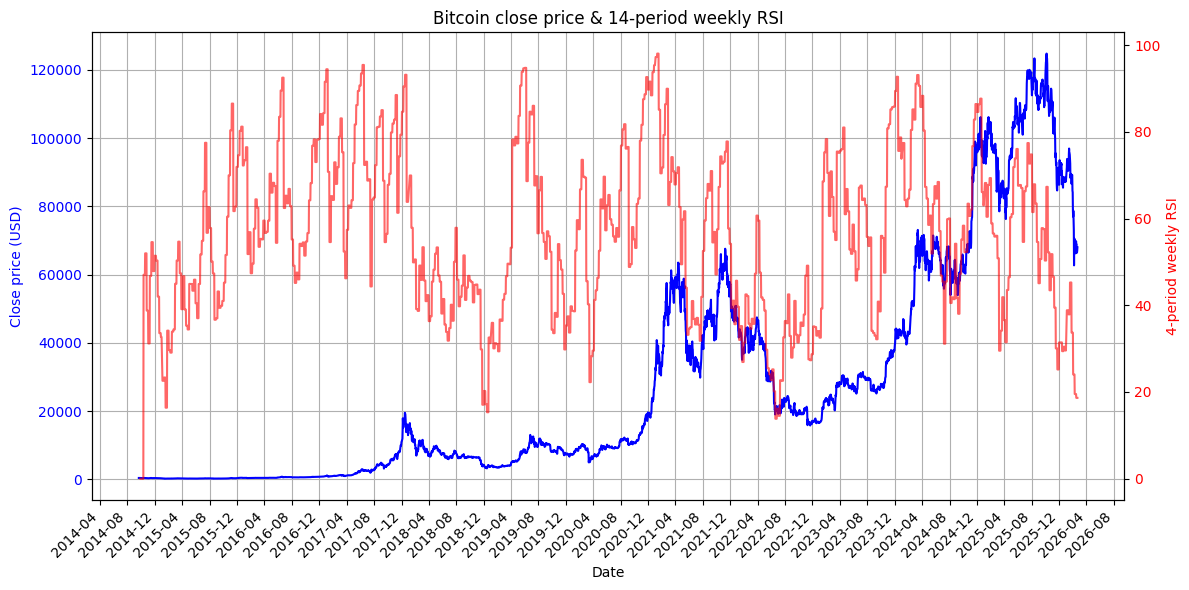

In [100]:

df_tmp = df.clone()
df_tmp = df_tmp.with_columns(
    pl.col("Date").str.strptime(pl.Datetime, format="%Y-%m-%d")
)

df_tmp = df_tmp.select(["Date", "Close", "14-period weekly RSI"]).to_pandas()

fig, ax1 = pyplot.subplots(figsize=(12,6))

# close price
ax1.plot(df_tmp["Date"], df_tmp["Close"], color="blue", label="BTC close price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Close price (USD)", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.grid(True)

# 14-period weekly RSI
ax2 = ax1.twinx()
ax2.plot(df_tmp["Date"], df_tmp["14-period weekly RSI"], color="red", label="14-period weekly RSI", alpha=0.6)
ax2.set_ylabel("4-period weekly RSI", color="red")
ax2.tick_params(axis='y', labelcolor="red")

ax1.xaxis.set_major_locator(dates.MonthLocator(interval=4))
ax1.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m'))
for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

pyplot.title("Bitcoin close price & 14-period weekly RSI")
pyplot.tight_layout()
pyplot.show()

### Simple Moving Average (SMA)

A value above the SMA indicates that BTC is overvalued, while a value below the SMA indicates that BTC is undervalued.
For the long term, the 200-period weekly SMA is the most appropriate indicator.

#### Calculation

In [101]:
sma_period = 200

df_sma = df_weekly.with_columns([
    pl.col("Close").rolling_mean(window_size=sma_period).alias("200-period weekly SMA")
])
df_sma

Week,Close,200-period weekly SMA
str,f64,f64
"""2014-38""",398.821014,null
"""2014-39""",377.181,null
"""2014-40""",320.51001,null
"""2014-41""",378.549011,null
"""2014-42""",389.54599,null
…,…,…
"""2026-03""",93634.429688,57594.720088
"""2026-04""",86572.21875,57793.478721
"""2026-05""",76974.445312,57946.083115


#### Merging

In [102]:
df_sma = df_sma.select(["Week", "200-period weekly SMA"])
df = df.join(df_sma, on="Week", how="inner")
df

Date,Close,High,Low,Open,Volume,Date_right,Fear and greed index value,Fear and greed index classification,Label,Period ID,Week,14-period weekly RSI,200-period weekly SMA
str,f64,f64,f64,f64,i64,str,i64,str,str,i64,str,f64,f64
"""2014-09-21""",398.821014,412.425995,393.181,408.084991,26580100,null,null,null,"""Buy zone""",0,"""2014-38""",NaN,null
"""2014-09-22""",402.152008,406.915985,397.130005,399.100006,24127600,null,null,null,"""Buy zone""",0,"""2014-38""",NaN,null
"""2014-09-23""",435.790985,441.557007,396.196991,402.09201,45099500,null,null,null,"""Buy zone""",0,"""2014-38""",NaN,null
"""2014-09-24""",423.204987,436.112,421.131989,435.751007,30627700,null,null,null,"""Buy zone""",0,"""2014-38""",NaN,null
"""2014-09-25""",411.574005,423.519989,409.467987,423.156006,26814400,null,null,null,"""Buy zone""",0,"""2014-38""",NaN,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2026-02-16""",68843.15625,70067.234375,67301.585938,68782.398438,33618145426,"""2026-02-16""",12,"""Extreme Fear""","""Neutral Zone""",3,"""2026-07""",18.641918,58231.724561
"""2026-02-17""",67494.21875,69201.867188,66615.28125,68843.09375,34866936040,"""2026-02-17""",10,"""Extreme Fear""","""Neutral Zone""",3,"""2026-07""",18.641918,58231.724561
"""2026-02-18""",66425.320312,68434.429688,65845.898438,67488.023438,33094301643,"""2026-02-18""",8,"""Extreme Fear""","""Neutral Zone""",3,"""2026-07""",18.641918,58231.724561


#### Data visualization

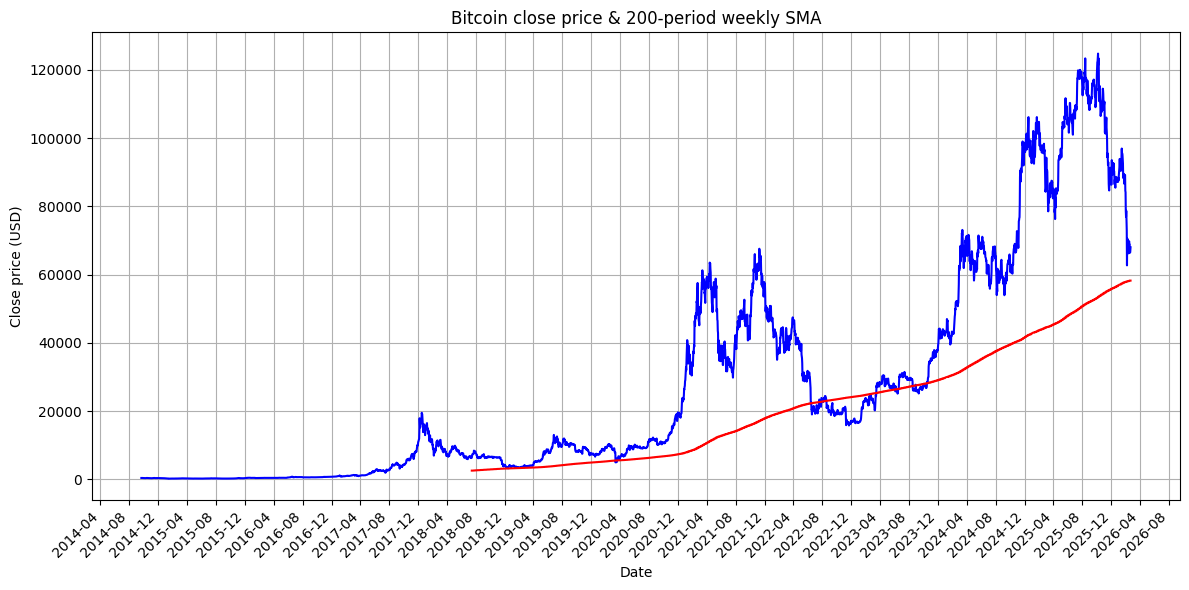

In [103]:
df_tmp = df.clone()
df_tmp = df_tmp.with_columns(
    pl.col("Date").str.strptime(pl.Datetime, format="%Y-%m-%d")
)

df_tmp = df_tmp.select(["Date", "Close", "200-period weekly SMA"]).to_pandas()

fig, ax = pyplot.subplots(figsize=(12,6))

# close price
ax.plot(df_tmp["Date"], df_tmp["Close"], color="blue", label="BTC close price")

# 200-period weekly SMA
ax.plot(df_tmp["Date"], df_tmp["200-period weekly SMA"], color="red", label="200-period weekly SMA")

ax.xaxis.set_major_locator(dates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m'))
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')


ax.set_xlabel("Date")
ax.set_ylabel("Close price (USD)")
ax.grid(True)

pyplot.title("Bitcoin close price & 200-period weekly SMA")
pyplot.tight_layout()
pyplot.show()

## Train and test split

In [252]:
X = df.drop('Label')
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

## Preprocessing

### Statistics

In [253]:
X_train_height_0 = X_train.height
print("X_train\n")
print(f"Total rows: {X_train_height_0}")
print("Missing values:")
print(X_train.to_pandas().isnull().sum())

X_test_height_0 = X_test.height
print("\nX_test\n")
print(f"Total rows: {X_test_height_0}")
print("Missing values:")
print(X_test.to_pandas().isnull().sum())

X_train

Total rows: 3308
Missing values:
Date                                      0
Close                                     0
High                                      0
Low                                       0
Open                                      0
Volume                                    0
Date_right                              986
Fear and greed index value              986
Fear and greed index classification     986
Period ID                                 0
Week                                      0
14-period weekly RSI                      5
200-period weekly SMA                  1108
dtype: int64

X_test

Total rows: 827
Missing values:
Date                                     0
Close                                    0
High                                     0
Low                                      0
Open                                     0
Volume                                   0
Date_right                             236
Fear and greed index value     

### Data cleaning

Close price, Fear and greed index, RSI and SMA cannot be imputed.

Using imputers (mean, median, most frequent, or KNN) does not make sense for the Close price, RSI or SMA values.

In [254]:

def remove_nulls(X: pl.DataFrame, y: pl.DataFrame, columns):
    X = X.to_pandas()
    y = y.to_pandas()

    X = X.dropna(subset=columns)
    y = y[X.index]

    return X, y

columns = ["Close", "14-period weekly RSI", "200-period weekly SMA", "Fear and greed index classification"]

X_train, y_train = remove_nulls(X_train, y_train, columns)
X_test, y_test = remove_nulls(X_test, y_test, columns)

print(f"X_train row deletion rate: {1 - (X_train.shape[0] / X_train_height_0)}")
print(f"X_test row deletion rate: {1 - (X_test.shape[0] / X_test_height_0)}")

X_train row deletion rate: 0.33524788391777505
X_test row deletion rate: 0.3313180169286578


### Data preprocessing

Almost 33% of the dataset will be removed, which is a significant portion.

In [255]:

class ColumnsRemover(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()
        X_transformed = X_transformed.drop(columns=self.columns)
        
        return X_transformed

print(X_train.dtypes)

cat_cols = X_train.select_dtypes(include=["str"]).columns
num_cols = X_train.columns.difference(cat_cols)

print(cat_cols)
print(num_cols)

set_config(display="diagram") 

numeric_preprocess = Pipeline([
    ("remover", ColumnsRemover(["Fear and greed index value", "High", "Low", "Open", "Period ID"])),
    ("scaler", StandardScaler()),
])

categorical_preprocess = Pipeline([
    ("remover", ColumnsRemover(["Date", "Date_right"])),
    ("scaler", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_preprocess, num_cols),
    ("cat", categorical_preprocess, cat_cols)
])

print("Preprocessing pipeline:")
display(preprocess)

Date                                       str
Close                                  float64
High                                   float64
Low                                    float64
Open                                   float64
Volume                                   int64
Date_right                                 str
Fear and greed index value             float64
Fear and greed index classification        str
Period ID                                int64
Week                                       str
14-period weekly RSI                   float64
200-period weekly SMA                  float64
dtype: object
Index(['Date', 'Date_right', 'Fear and greed index classification', 'Week'], dtype='str')
Index(['14-period weekly RSI', '200-period weekly SMA', 'Close',
       'Fear and greed index value', 'High', 'Low', 'Open', 'Period ID',
       'Volume'],
      dtype='str')
Preprocessing pipeline:


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `